In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81
m1 = m2 = 1.0
l1 = l2 = 1.0
t_end = 20.0
y0 = np.array([0.10, 0.15, 0.0, 0.0])
steps = [0.04, 0.02, 0.01]
methods = ["RK4", "Адамс–Бэшфорт 2"]


def rhs(y):
    theta1, theta2, v1, v2 = y
    delta = theta1 - theta2
    a = (m1 + m2) * l1**2
    b = m2 * l1 * l2 * np.cos(delta)
    c = m2 * l2**2
    r1 = -m2*l1*l2*np.sin(delta)*v2**2 - (m1+m2)*g*l1*np.sin(theta1)
    r2 = m2*l1*l2*np.sin(delta)*v1**2 - m2*g*l2*np.sin(theta2)
    det = a*c - b*b
    acc1 = (c*r1 - b*r2) / det
    acc2 = (a*r2 - b*r1) / det
    return np.array([v1, v2, acc1, acc2])


def rk4_step(y, h):
    k1 = rhs(y)
    k2 = rhs(y + h*k1/2)
    k3 = rhs(y + h*k2/2)
    k4 = rhs(y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6


def solve(method, h):
    n = round(t_end / h)
    t = np.linspace(0, t_end, n + 1)
    h = t[1] - t[0]
    y = np.empty((n + 1, 4))
    y[0] = y0
    if method == "RK4":
        for i in range(n):
            y[i + 1] = rk4_step(y[i], h)
    elif method == "Адамс–Бэшфорт 2":
        y[1] = rk4_step(y[0], h)
        f_previous = rhs(y[0])
        f_current = rhs(y[1])
        for i in range(1, n):
            y[i + 1] = y[i] + h*(3*f_current - f_previous)/2
            f_previous, f_current = f_current, rhs(y[i + 1])
    else:
        raise ValueError(method)
    return t, y


def energy(y):
    theta1, theta2, v1, v2 = y.T
    kinetic = ((m1+m2)*l1**2*v1**2/2 + m2*l2**2*v2**2/2
               + m2*l1*l2*v1*v2*np.cos(theta1-theta2))
    potential = (m1+m2)*g*l1*(1-np.cos(theta1)) + m2*g*l2*(1-np.cos(theta2))
    return kinetic + potential


def lower_position(y):
    theta1, theta2 = y[:, 0], y[:, 1]
    x = l1*np.sin(theta1) + l2*np.sin(theta2)
    z = -l1*np.cos(theta1) - l2*np.cos(theta2)
    return x, z

results = {(method, h): solve(method, h) for method in methods for h in steps}
h_ref = min(steps) / 8
t_ref, y_ref = solve("RK4", h_ref)
E0 = energy(y0.reshape(1, 4))[0]
print(f"θ₁(0) = {y0[0]} рад; θ₂(0) = {y0[1]} рад; ω₁(0) = ω₂(0) = 0 рад/с")
print("Углы отсчитываются от вертикали вниз; начало координат — верхний подвес.")
print("Нулевая потенциальная энергия соответствует нижнему положению равновесия.")
print(f"m₁ = m₂ = {m1} кг; l₁ = l₂ = {l1} м; g = {g} м/с²; E(0) = {E0:.8f} Дж")

θ₁(0) = 0.1 рад; θ₂(0) = 0.15 рад; ω₁(0) = ω₂(0) = 0 рад/с
Углы отсчитываются от вертикали вниз; начало координат — верхний подвес.
Нулевая потенциальная энергия соответствует нижнему положению равновесия.
m₁ = m₂ = 1.0 кг; l₁ = l₂ = 1.0 м; g = 9.81 м/с²; E(0) = 0.20817400 Дж


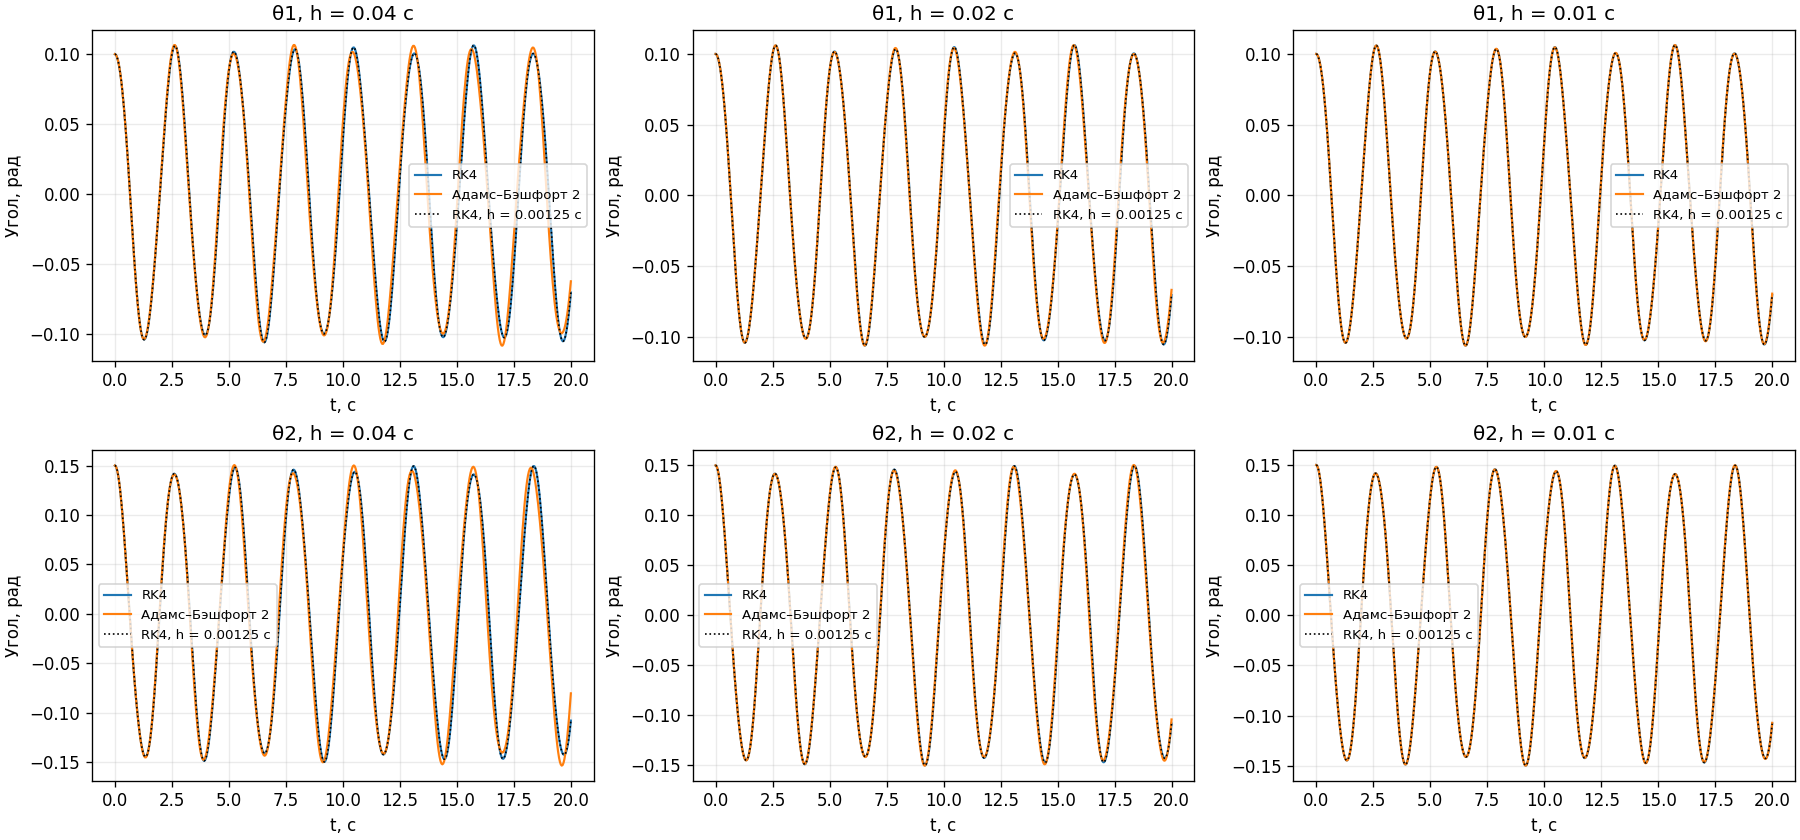

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
for col, h in enumerate(steps):
    for row in range(2):
        ax = axes[row, col]
        for method in methods:
            t, y = results[method, h]
            ax.plot(t, y[:, row], label=method, lw=1.3)
        ax.plot(t_ref, y_ref[:, row], "k:", lw=1, label="RK4, h = 0.00125 с")
        ax.set(title=f"θ{row+1}, h = {h} с", xlabel="t, с", ylabel="Угол, рад")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
plt.show()

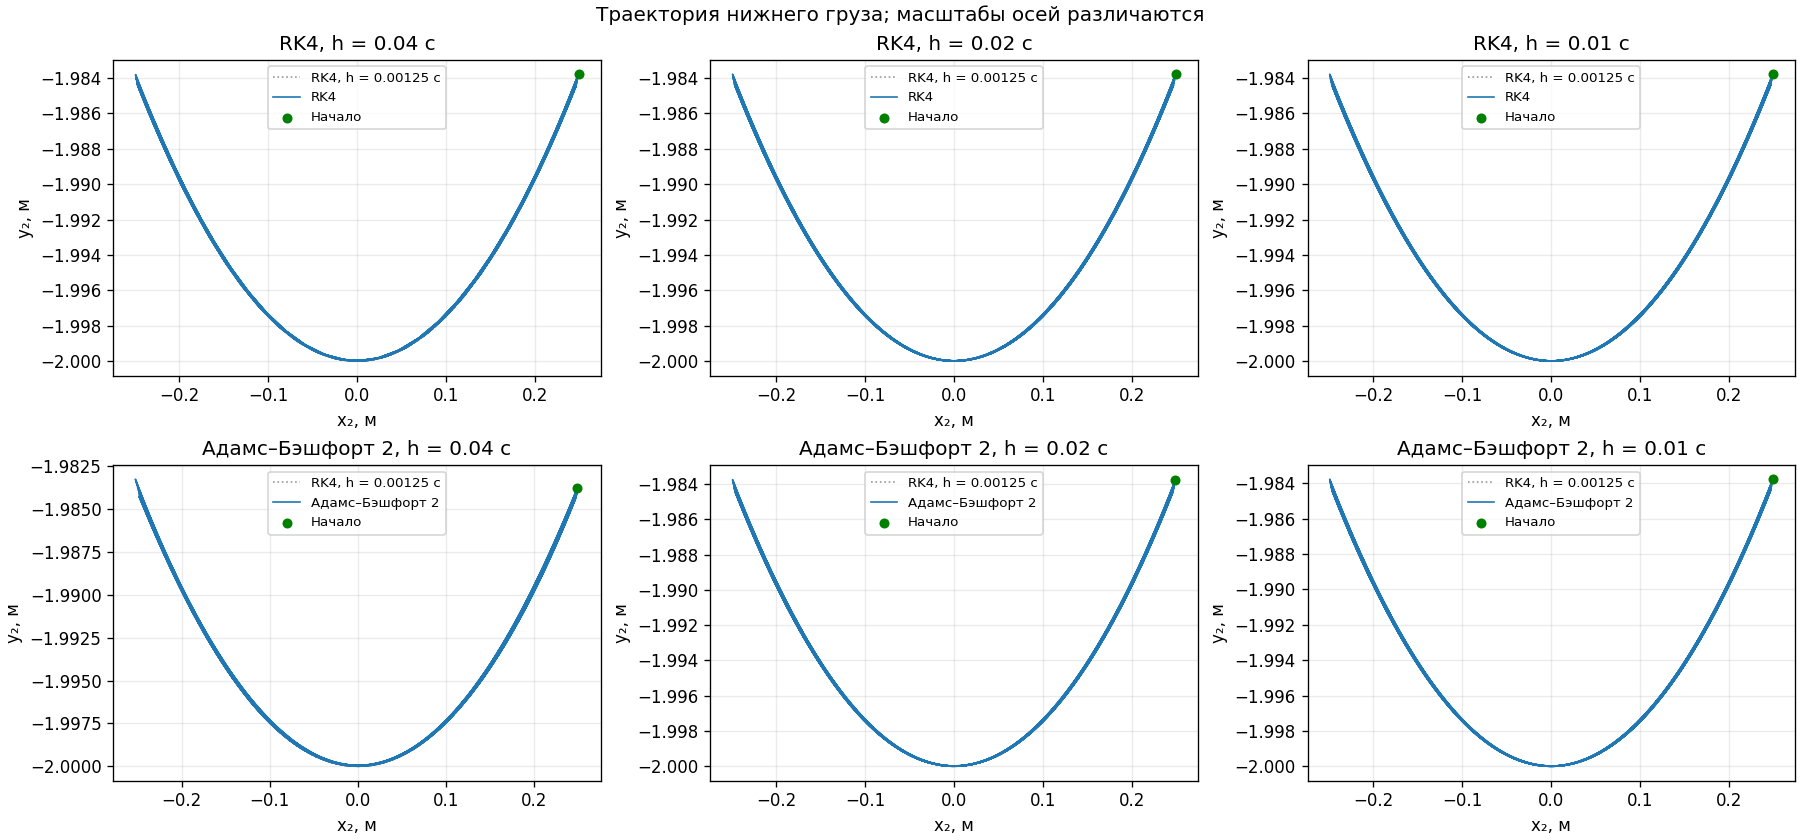

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
x_ref, z_ref = lower_position(y_ref)
for row, method in enumerate(methods):
    for col, h in enumerate(steps):
        ax = axes[row, col]
        t, y = results[method, h]
        x, z = lower_position(y)
        ax.plot(x_ref, z_ref, color="0.6", ls=":", lw=1, label="RK4, h = 0.00125 с")
        ax.plot(x, z, lw=1, label=method)
        ax.scatter(x[0], z[0], color="green", s=25, zorder=3, label="Начало")
        ax.set(title=f"{method}, h = {h} с", xlabel="x₂, м", ylabel="y₂, м")
        ax.ticklabel_format(axis="y", style="plain", useOffset=False)
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
fig.suptitle("Траектория нижнего груза; масштабы осей различаются")
plt.show()

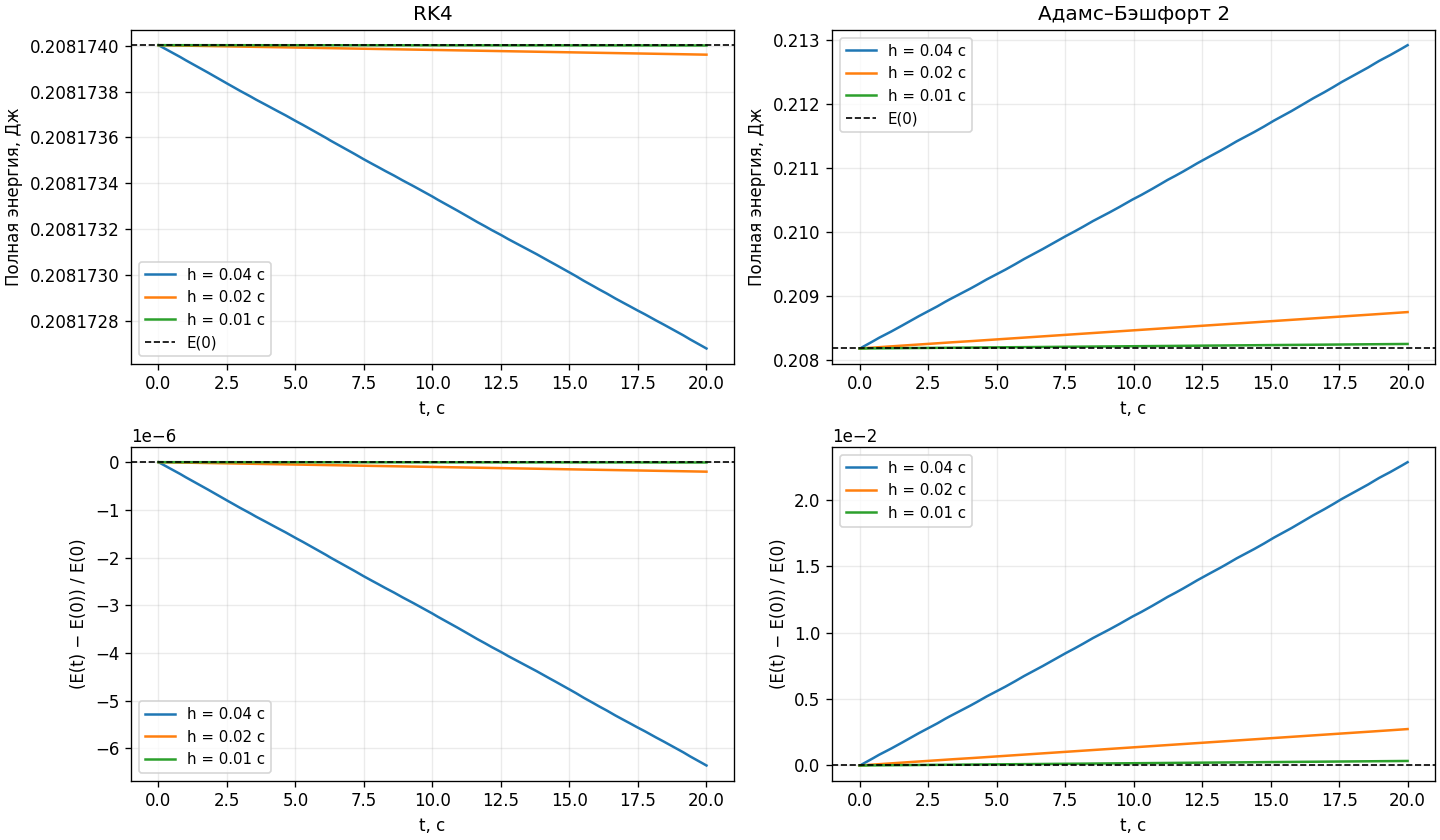

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for col, method in enumerate(methods):
    for h in steps:
        t, y = results[method, h]
        E = energy(y)
        axes[0, col].plot(t, E, label=f"h = {h} с")
        axes[1, col].plot(t, (E-E0)/E0, label=f"h = {h} с")
    axes[0, col].axhline(E0, color="black", ls="--", lw=1, label="E(0)")
    axes[0, col].set(title=method, xlabel="t, с", ylabel="Полная энергия, Дж")
    axes[0, col].ticklabel_format(axis="y", style="plain", useOffset=False)
    axes[1, col].axhline(0, color="black", ls="--", lw=1)
    axes[1, col].set(xlabel="t, с", ylabel="(E(t) − E(0)) / E(0)")
    axes[1, col].ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
for ax in axes.flat:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
plt.show()

In [5]:
print("Сравнение с опорным расчётом RK4: h =", h_ref, "с")
print(f"{'Метод':<20} {'h, с':>7} {'max |Δθ₁|, рад':>17} {'max |Δθ₂|, рад':>17} {'max |ΔE/E₀|':>16}")
errors = {}
for method in methods:
    errors[method] = []
    for h in steps:
        t, y = results[method, h]
        stride = round(h / h_ref)
        reference = y_ref[::stride]
        error = np.max(np.abs(y[:, :2] - reference[:, :2]), axis=0)
        energy_error = np.max(np.abs(energy(y)-E0)) / E0
        errors[method].append(np.max(error))
        print(f"{method:<20} {h:7.3f} {error[0]:17.6e} {error[1]:17.6e} {energy_error:16.6e}")
    orders = np.log2(np.array(errors[method][:-1]) / np.array(errors[method][1:]))
    print("Оценка порядка при делении шага на 2:", ", ".join(f"{p:.3f}" for p in orders))

Сравнение с опорным расчётом RK4: h = 0.00125 с
Метод                   h, с    max |Δθ₁|, рад    max |Δθ₂|, рад      max |ΔE/E₀|
RK4                    0.040      1.125256e-05      1.503977e-05     6.361927e-06
RK4                    0.020      7.031991e-07      9.413231e-07     1.993411e-07
RK4                    0.010      4.392454e-08      5.883261e-08     6.244916e-09
Оценка порядка при делении шага на 2: 3.998, 4.000
Адамс–Бэшфорт 2        0.040      2.543257e-02      3.153399e-02     2.281551e-02
Адамс–Бэшфорт 2        0.020      6.150235e-03      7.802315e-03     2.740064e-03
Адамс–Бэшфорт 2        0.010      1.501304e-03      1.938088e-03     3.411378e-04
Оценка порядка при делении шага на 2: 2.015, 2.009
